In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [185]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SVC

In [186]:
x,y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_redundant=0, n_clusters_per_class=1)

In [187]:
x

array([[-0.80527602,  0.63847996],
       [ 0.23031659,  1.10993769],
       [ 1.35054169, -2.41755062],
       ...,
       [-1.04972539,  0.32889217],
       [-1.16607462,  1.05530005],
       [ 0.55315461, -2.00498537]], shape=(1000, 2))

In [188]:
y

array([1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,

<Axes: xlabel='0', ylabel='1'>

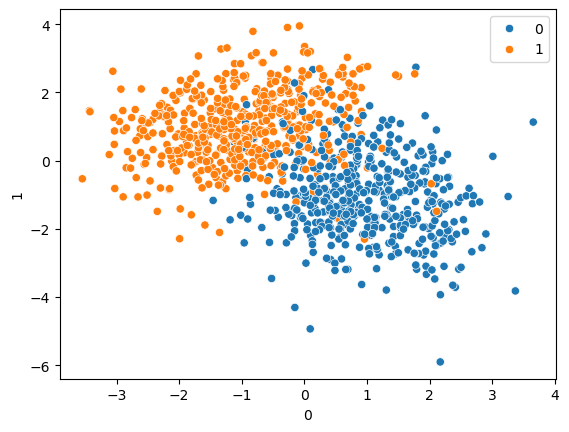

In [189]:
sns.scatterplot(x=pd.DataFrame(x)[0], y=pd.DataFrame(x)[1], hue=y)

In [190]:
xtr,xt,ytr,yt = train_test_split(x,y,test_size=0.2,random_state=10)

In [191]:
svc = SVC(kernel='linear')#use rbf, poly, sigmoid for non linear data
svc.fit(xtr,ytr)
yp = svc.predict(xt)

In [192]:
print(classification_report(yt,yp))
print(confusion_matrix(yt,yp))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       108
           1       0.95      0.91      0.93        92

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

[[104   4]
 [  8  84]]


In [193]:
rbf = SVC(kernel='rbf')#use rbf, poly, sigmoid for non linear data
rbf.fit(xtr,ytr)
yp1 = rbf.predict(xt)
print(classification_report(yt,yp1))
print(confusion_matrix(yt,yp1))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       108
           1       0.96      0.92      0.94        92

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200

[[104   4]
 [  7  85]]


In [194]:
poly = SVC(kernel='poly')#use rbf, poly, sigmoid for non linear data
poly.fit(xtr,ytr)
yp2 = poly.predict(xt)
print(classification_report(yt,yp2))
print(confusion_matrix(yt,yp2))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       108
           1       0.99      0.87      0.92        92

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200

[[107   1]
 [ 12  80]]


In [195]:
sigmoid = SVC(kernel='sigmoid')#use rbf, poly, sigmoid for non linear data
sigmoid.fit(xtr,ytr)
yp3 = sigmoid.predict(xt)
print(classification_report(yt,yp3))
print(confusion_matrix(yt,yp3))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       108
           1       0.89      0.87      0.88        92

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200

[[98 10]
 [12 80]]


Hyperparameter Tuning

In [196]:
from sklearn.model_selection import GridSearchCV

grid = {'C':[0.1,1,10,100], 'gamma':[1,0.1,0.01,0.001], 'kernel':['rbf','linear','poly','sigmoid']}

In [197]:
grid_search = GridSearchCV(SVC(),grid,refit=True,cv=5,verbose=2)

In [198]:
grid_search.fit(xtr,ytr)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [199]:
yp5 = grid_search.predict(xt)
print(classification_report(yt,yp5))
print(confusion_matrix(yt,yp5))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       108
           1       0.95      0.91      0.93        92

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

[[104   4]
 [  8  84]]


SVM Kernels & Depth

In [200]:
x = np.linspace(-5,5,100)
y = np.sqrt(10**2-x**2)
y = np.hstack((y,-y))
x = np.hstack((x,x))


x1 = np.linspace(-5,5,100)
y1 = np.sqrt(5**2-x1**2)
y1 = np.hstack((y1,-y1))
x1 = np.hstack((x1,x1))


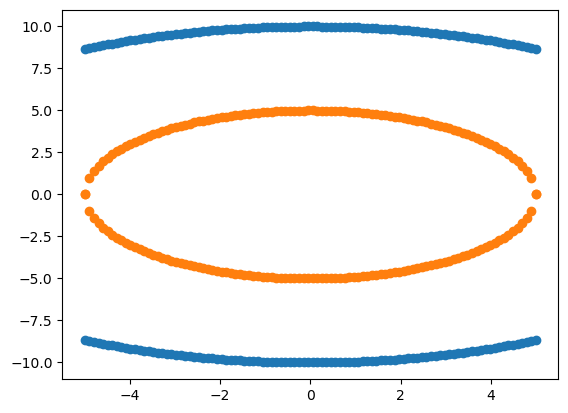

In [201]:
plt.scatter(x,y)
plt.scatter(x1,y1)

In [202]:
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['x1','x2'])
df1['y'] = 0
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns=['x1','x2'])
df2['y'] = 1
df = pd.concat([df1,df2],ignore_index=True)
df.head(5)

,x1,x2,y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [203]:
xk = df.iloc[:,:2].values
yk = df.y.values

In [204]:
xtrain,xtest,ytrain,ytest = train_test_split(xk,yk,test_size=0.2,random_state=10)

In [205]:
df['x1^2'] = df.x1**2
df['x2^2'] = df.x2**2
df['x1*x2'] = df.x1*df.x2
df.head()

,x1,x2,y,x1^2,x2^2,x1*x2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [206]:
from plotly import express as px    

px.scatter_3d(df,x='x1',y='x2',z='x1*x2',color='y')

SVR

In [207]:
data = sns.load_dataset('tips')
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [208]:
data.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [209]:
data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [240]:
data['sex'] = data['sex'].astype(str).str.strip().str.capitalize()

In [241]:
x = data[['tip', 'sex', 'smoker', 'day', 'time', 'size']]
y = data['total_bill']

In [242]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25,random_state=10)

In [243]:
xtrain

,tip,sex,smoker,day,time,size
58,1.76,Male,Yes,Sat,Dinner,2
1,1.66,Male,No,Sun,Dinner,3
2,3.50,Male,No,Sun,Dinner,3
68,2.01,Male,No,Sat,Dinner,2
184,3.00,Male,Yes,Sun,Dinner,2
...,...,...,...,...,...,...
64,2.64,Male,No,Sat,Dinner,3
15,3.92,Male,No,Sun,Dinner,2
228,2.72,Male,No,Sat,Dinner,2
125,4.20,Female,No,Thur,Lunch,6


In [255]:
xtrain['sex'].value_counts()


sex
1    116
0     67
Name: count, dtype: int64

In [256]:
xtrain['smoker'].value_counts()

smoker
0    118
1     65
Name: count, dtype: int64

In [257]:
xtrain['time'].value_counts()

time
0    133
1     50
Name: count, dtype: int64

In [244]:
xtest

,tip,sex,smoker,day,time,size
162,2.00,Female,No,Sun,Dinner,3
60,3.21,Male,Yes,Sat,Dinner,2
61,2.00,Male,Yes,Sat,Dinner,2
63,3.76,Male,Yes,Sat,Dinner,4
69,2.09,Male,Yes,Sat,Dinner,2
...,...,...,...,...,...,...
201,2.01,Female,Yes,Thur,Lunch,2
149,2.00,Male,No,Thur,Lunch,2
175,3.11,Male,Yes,Sun,Dinner,2
226,2.00,Female,Yes,Fri,Lunch,2


In [245]:
#Encoding categorical data One hot encoding (for day) and label encoding (for sex,smoker,time,size)
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

In [249]:
xtrain['sex'] = le1.fit_transform(xtrain['sex'])
xtrain['smoker'] = le2.fit_transform(xtrain['smoker'])
xtrain['time'] = le3.fit_transform(xtrain['time'])
xtest['sex'] = le1.transform(xtest['sex'])
xtest['smoker'] = le2.transform(xtest['smoker'])
xtest['time'] = le3.transform(xtest['time'])

In [250]:
xtrain

,tip,sex,smoker,day,time,size
58,1.76,1,1,Sat,0,2
1,1.66,1,0,Sun,0,3
2,3.50,1,0,Sun,0,3
68,2.01,1,0,Sat,0,2
184,3.00,1,1,Sun,0,2
...,...,...,...,...,...,...
64,2.64,1,0,Sat,0,3
15,3.92,1,0,Sun,0,2
228,2.72,1,0,Sat,0,2
125,4.20,0,0,Thur,1,6


In [252]:
xtest

,tip,sex,smoker,day,time,size
162,2.00,0,0,Sun,0,3
60,3.21,1,1,Sat,0,2
61,2.00,1,1,Sat,0,2
63,3.76,1,1,Sat,0,4
69,2.09,1,1,Sat,0,2
...,...,...,...,...,...,...
201,2.01,0,1,Thur,1,2
149,2.00,1,0,Thur,1,2
175,3.11,1,1,Sun,0,2
226,2.00,0,1,Fri,1,2


In [259]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
xtrain = ct.fit_transform(xtrain)
xtest = ct.transform(xtest)

In [260]:
xtrain

array([[0., 1., 0., ..., 1., 0., 2.],
       [0., 0., 1., ..., 0., 0., 3.],
       [0., 0., 1., ..., 0., 0., 3.],
       ...,
       [0., 1., 0., ..., 0., 0., 2.],
       [0., 0., 0., ..., 0., 1., 6.],
       [0., 0., 1., ..., 0., 0., 2.]], shape=(183, 9))

In [261]:
xtest

array([[0.  , 0.  , 1.  , 0.  , 2.  , 0.  , 0.  , 0.  , 3.  ],
       [0.  , 1.  , 0.  , 0.  , 3.21, 1.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 0.  , 2.  , 1.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 0.  , 3.76, 1.  , 1.  , 0.  , 4.  ],
       [0.  , 1.  , 0.  , 0.  , 2.09, 1.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 0.  , 1.  , 5.  , 1.  , 1.  , 1.  , 2.  ],
       [0.  , 0.  , 1.  , 0.  , 3.51, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 0.  , 5.16, 1.  , 1.  , 0.  , 4.  ],
       [0.  , 0.  , 1.  , 0.  , 5.  , 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 0.  , 3.6 , 1.  , 0.  , 0.  , 3.  ],
       [0.  , 0.  , 1.  , 0.  , 5.65, 1.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 0.  , 2.5 , 0.  , 1.  , 0.  , 3.  ],
       [0.  , 0.  , 0.  , 1.  , 1.44, 1.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 0.  , 3.09, 0.  , 1.  , 0.  , 4.  ],
       [0.  , 0.  , 1.  , 0.  , 2.  , 1.  , 0.  , 0.  , 4.  ],
       [0.  , 0.  , 0.  , 1.  , 1.36, 0.  , 0.  , 1.  ,

In [262]:
from sklearn.svm import SVR

In [263]:
svr = SVR()

In [264]:
svr.fit(xtrain,ytrain)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [265]:
yprd = svr.predict(xtest)

In [268]:
from sklearn.metrics import r2_score
r2 = r2_score(ytest, yprd)
print(r2)

0.4603150286622254


In [270]:
grid = {'C':[0.1,1,10,100], 'gamma':[1,0.1,0.01,0.001], 'kernel':['rbf','linear','poly','sigmoid']}

grid_search = GridSearchCV(SVR(),grid,refit=True,cv=5,verbose=2)

grid_search.fit(xtrain,ytrain)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [271]:
from sklearn.metrics import r2_score
r2 = r2_score(ytest, grid_search.predict(xtest))
print(r2)

0.5474104759985571
